# T0 v. Plasmid Analysis

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [106]:
ABE_master_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/ABE_master_LFC_table.csv')
CBE_master_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/CBE_master_LFC_table.csv')

ABE_editing_master = pd.read_csv('../../screening_data/04_editing/ABE_editing_master.csv')
CBE_editing_master = pd.read_csv('../../screening_data/04_editing/CBE_editing_master.csv')

In [108]:
def KLIFS_annotator(comb):
    KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

    genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

    k_holder = []
    for gene in genes:
        k = list(KLIFS[gene])
        k_holder.append(k)

    klifs_dict = dict(zip(genes, k_holder))

    in_pocket_hg = []
    KLIFS_idx_hg = []
    in_pocket_sav = []
    KLIFS_idx_sav = []

    for i, val in comb.iterrows():
        g = val['Gene']
        l = klifs_dict[g]
        if val['Top_HGVSp_Codon'] in l:
            in_pocket_hg.append(True)
            KLIFS_idx_hg.append(l.index(val['Top_HGVSp_Codon'])+1)

        if val['Top_HGVSp_Codon'] not in l:
            in_pocket_hg.append(False)
            KLIFS_idx_hg.append(None)

        if val['Codon']!='WT':
            if int(val['Codon']) in l:
                in_pocket_sav.append(True)
                KLIFS_idx_sav.append(l.index(int(val['Codon']))+1)

            if int(val['Codon']) not in l:
                in_pocket_sav.append(False)
                KLIFS_idx_sav.append(None)
        else:
            in_pocket_sav.append(False)
            KLIFS_idx_sav.append(None)

    comb['ATP_binding_pocket_top'] = in_pocket_hg
    comb['KLIFS_index_top'] = KLIFS_idx_hg
    comb['ATP_binding_pocket_SAV'] = in_pocket_sav
    comb['KLIFS_index_SAV'] = KLIFS_idx_sav

    return comb

In [109]:
ABE_editing_master = KLIFS_annotator(ABE_editing_master)
CBE_editing_master = KLIFS_annotator(CBE_editing_master)


In [165]:
screen_ids = ['Subpool1', 'Subpool2', 'Subpool3','SY-5609', 'Iterative']

s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID']=='Subpool3')]
s2 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='DMSO') & (CBE_master_LFC['Screen_ID']=='Subpool3')]

md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')
md2 = pd.merge(CBE_editing_master, s2, on='gRNA_id')

assert list(md1['HGVSp'])==list(md2['HGVSp'])
assert list(md1['gRNA_id'])==list(md2['gRNA_id'])


In [169]:
cond = 'PALBO'
l1 = list(md2[(md2[f'LFC_median_{cond}_DMSO']>=0) & (md2[f'FDR_{cond}_DMSO']<.1) & (md2['ATP_binding_pocket_SAV']==True) & (md2['%Reads']>=20)]['gRNA_id'])
l1


['gRNA_CDK4_targ_7657',
 'gRNA_CDK4_targ_7658',
 'gRNA_CDK4_targ_7658',
 'gRNA_CDK6_targ_8145',
 'gRNA_CDK6_targ_8145',
 'gRNA_CDK6_targ_8177',
 'gRNA_CDK6_targ_8177',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426',
 'gRNA_CDK6_targ_8426']

In [174]:
md2[(md2[f'LFC_median_{cond}_DMSO']>=0) & (md2[f'FDR_{cond}_DMSO']<.1) & (md2['ATP_binding_pocket_SAV']==True) & (md2['%Reads']>=10)]

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_2000_REP3_T0,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0
7452,gRNA_CDK4_targ_7656,CDK4,49858,E56K,16.647278,56,V57I,57,9.992378,46.869108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7453,gRNA_CDK4_targ_7656,CDK4,49858,V57I,14.611497,57,V57I,57,9.992378,46.869108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7470,gRNA_CDK4_targ_7657,CDK4,161757,E56K,82.879257,56,E56K,56,77.693083,6.579623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7475,gRNA_CDK4_targ_7658,CDK4,174101,E56K,74.742822,56,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7476,gRNA_CDK4_targ_7658,CDK4,174101,R55H,27.825802,55,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7477,gRNA_CDK4_targ_7658,CDK4,174101,E56Q,14.820708,56,E56K,56,41.541404,2.968392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13028,gRNA_CDK6_targ_8145,CDK6,56402,D104N,25.398036,104,D104N,104,23.940640,40.567710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13029,gRNA_CDK6_targ_8145,CDK6,56402,L105F,22.926492,105,D104N,104,23.940640,40.567710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13471,gRNA_CDK6_targ_8177,CDK6,84312,R60H,74.425942,60,R60H_E61K,60,51.114907,5.518787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13472,gRNA_CDK6_targ_8177,CDK6,84312,E61K,60.366259,61,R60H_E61K,60,51.114907,5.518787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
md1.loc[md1['gRNA_id'].isin(l1), 'value'] = True
md1.loc[~md1['gRNA_id'].isin(l1), 'value'] = False


<Axes: xlabel='value', ylabel='LFC_median_T0_Plasmid'>

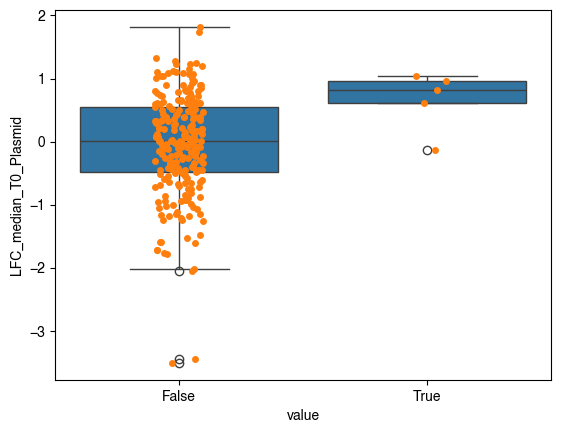

In [176]:
kinase_subset = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=20)]
kinase_subset = kinase_subset.drop_duplicates(subset='gRNA_id')

sns.boxplot(data=kinase_subset, x='value', y='LFC_median_T0_Plasmid')
sns.stripplot(data=kinase_subset, x='value', y='LFC_median_T0_Plasmid')

In [233]:
s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]

md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')

k2 = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=20) & (md1['Mutation_Class_SAV']=='Missense')]
#md1[md1['ATP_binding_pocket_SAV']==True]['KLIFS_index_SAV'])

alphaC = list(range(20,31))
k2.loc[k2['KLIFS_index_SAV'].isin(alphaC), 'value']=True
k2.loc[~k2['KLIFS_index_SAV'].isin(alphaC), 'value']=False

k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0,value
2522,gRNA_CDK19_targ_6521,CDK19,45092,V159I,25.652000,159,V159I,159,16.614921,36.669476,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2537,gRNA_CDK19_targ_6522,CDK19,39769,V159I,55.691619,159,V159I,159,50.461415,15.977269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2538,gRNA_CDK19_targ_6522,CDK19,39769,V159L,26.447736,159,V159I,159,50.461415,15.977269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2547,gRNA_CDK19_targ_6526,CDK19,168260,R150K,60.428504,150,R150K,150,49.421134,22.121716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2567,gRNA_CDK19_targ_6529,CDK19,85056,V147I,29.390049,147,W146*,146,41.174050,12.424755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81655,gRNA_CDK6_targ_8455,CDK6,6093,A17V,64.483834,17,A17V,17,59.478090,16.330215,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81669,gRNA_CDK6_targ_8456,CDK6,10615,A17V,79.717381,17,A17V,17,69.769195,0.357984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81687,gRNA_CDK6_targ_8457,CDK6,35512,A17V,69.216040,17,A17V,17,57.374972,5.660059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
81714,gRNA_CDK6_targ_8458,CDK6,29601,A17V,46.194385,17,A17V,17,40.826323,26.252491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

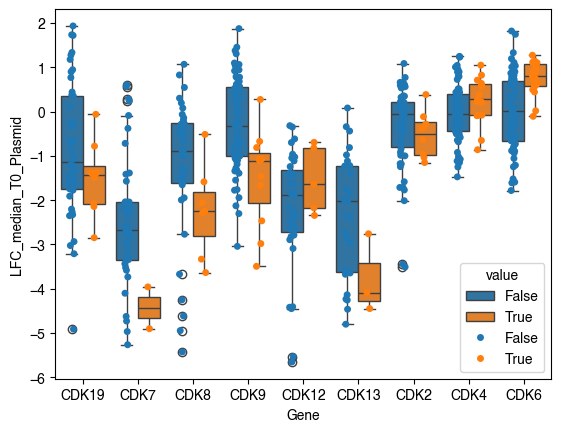

In [234]:
k2 = k2.drop_duplicates(subset='gRNA_id')
sns.boxplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)
sns.stripplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)

In [238]:
g = 'CDK12'
scipy.stats.ttest_ind(k2[(k2['Gene']==g) & (k2['value']==True)]['LFC_median_T0_Plasmid'],k2[(k2['Gene']==g) & (k2['value']==False)]['LFC_median_T0_Plasmid'] )

Ttest_indResult(statistic=1.1182724589829058, pvalue=0.2704705020660068)

In [222]:
s1 = ABE_master_LFC[(ABE_master_LFC['Base_Value']=='Plasmid') & (ABE_master_LFC['Screen_ID'].isin(['Subpool1','Subpool2','Subpool3']))]

md1 = pd.merge(ABE_editing_master, s1, on='gRNA_id')

k2 = md1[(md1['ATP_binding_pocket_SAV']==True) & (md1['%Reads']>=40) & (md1['Mutation_Class_SAV']=='Missense')]
#md1[md1['ATP_binding_pocket_SAV']==True]['KLIFS_index_SAV'])

alphaC = list(range(20,31))
k2.loc[k2['KLIFS_index_SAV'].isin(alphaC), 'value']=True
k2.loc[~k2['KLIFS_index_SAV'].isin(alphaC), 'value']=False

k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,SY-5609_10nM_REP1_T0,SY-5609_10nM_REP2_T0,SY-5609_10nM_REP3_T0,LFC_median_SY-5609_100nM_T0,LFC_median_SY-5609_10nM_T0,LFC_avg_SY-5609_100nM_T0,LFC_avg_SY-5609_10nM_T0,FDR_SY-5609_100nM_T0,FDR_SY-5609_10nM_T0,value
1726,gRNA_CDK19_targ_6521,CDK19,50912,V159A,84.394642,159,V159A_M160T,159,47.788341,14.532920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1730,gRNA_CDK19_targ_6522,CDK19,66168,V159A,87.187160,159,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1731,gRNA_CDK19_targ_6522,CDK19,66168,L158P,67.212248,158,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1737,gRNA_CDK19_targ_6523,CDK19,16573,I157T,43.878598,157,I157T,157,42.454595,54.371568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1748,gRNA_CDK19_targ_6527,CDK19,262662,V147A,65.890765,147,V147A,147,35.146690,10.053605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52431,gRNA_CDK6_targ_8455,CDK6,1530,A17V,61.045752,17,A17V,17,50.849673,28.300654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52436,gRNA_CDK6_targ_8456,CDK6,2156,E18G,77.319109,18,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52437,gRNA_CDK6_targ_8456,CDK6,2156,I19V,68.506494,19,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52441,gRNA_CDK6_targ_8457,CDK6,7437,E18G,57.590426,18,E18G,18,50.221864,21.527498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [ ]:
g = 'CDK4'
scipy.stats.ttest_ind(k2[(k2['Gene']==g) & (k2['value']==True)]['LFC_median_T0_Plasmid'],k2[(k2['Gene']==g) & (k2['value']==False)]['LFC_median_T0_Plasmid'] )

Ttest_indResult(statistic=0.6345666569482504, pvalue=0.5278095430934957)

<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

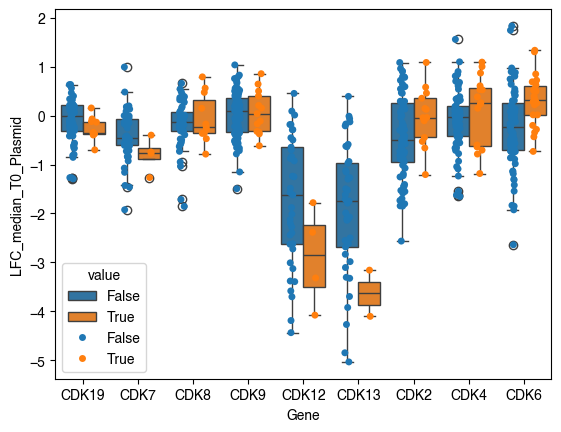

In [223]:
k2 = k2.drop_duplicates(subset='gRNA_id')
sns.boxplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)
sns.stripplot(data=k2, x='Gene', y='LFC_median_T0_Plasmid', hue='value', dodge=True)

In [221]:
k2

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,SY-5609_10nM_REP1_T0,SY-5609_10nM_REP2_T0,SY-5609_10nM_REP3_T0,LFC_median_SY-5609_100nM_T0,LFC_median_SY-5609_10nM_T0,LFC_avg_SY-5609_100nM_T0,LFC_avg_SY-5609_10nM_T0,FDR_SY-5609_100nM_T0,FDR_SY-5609_10nM_T0,value
1712,gRNA_CDK19_targ_6519,CDK19,113946,V159A,26.860092,159,M160T,160,24.035947,25.375178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1721,gRNA_CDK19_targ_6520,CDK19,121547,V159A,37.499074,159,M160T,160,37.931006,18.517117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1726,gRNA_CDK19_targ_6521,CDK19,50912,V159A,84.394642,159,V159A_M160T,159,47.788341,14.532920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1730,gRNA_CDK19_targ_6522,CDK19,66168,V159A,87.187160,159,L158P_V159A,158,60.594245,9.805344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1737,gRNA_CDK19_targ_6523,CDK19,16573,I157T,43.878598,157,I157T,157,42.454595,54.371568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52418,gRNA_CDK6_targ_8454,CDK6,4893,I19V,65.849172,19,I19V,19,42.489270,28.305743,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52431,gRNA_CDK6_targ_8455,CDK6,1530,A17V,61.045752,17,A17V,17,50.849673,28.300654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52436,gRNA_CDK6_targ_8456,CDK6,2156,E18G,77.319109,18,E18G_I19V,18,65.538033,14.564007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
52441,gRNA_CDK6_targ_8457,CDK6,7437,E18G,57.590426,18,E18G,18,50.221864,21.527498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [216]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

KLIFS[:50]

,KLIFS_idx,CDK7,CDK7_seq,CDK8,CDK8_seq,CDK19,CDK19_seq,CDK9,CDK9_seq,CDK12,CDK12_seq,CDK13,CDK13_seq,CDK2,CDK2_seq,CDK4,CDK4_seq,CDK6,CDK6_seq
0,I:1,16.0,D,25.0,C,25.0,C,23.0,A,731.0,G,709.0,G,8.0,E,10.0,A,17.0,A
1,I:2,17.0,F,26.0,K,26.0,K,24.0,K,732.0,I,710.0,I,9.0,K,11.0,E,18.0,E
2,I:3,18.0,L,27.0,V,27.0,V,25.0,I,733.0,I,711.0,I,10.0,I,12.0,I,19.0,I
3,g.l:4,19.0,G,28.0,G,28.0,G,26.0,G,734.0,G,712.0,G,11.0,G,13.0,G,20.0,G
4,g.l:5,20.0,E,29.0,R,29.0,R,27.0,Q,735.0,E,713.0,E,12.0,E,14.0,V,21.0,E
5,g.l:6,21.0,G,30.0,G,30.0,G,28.0,G,736.0,G,714.0,G,13.0,G,15.0,G,22.0,G
6,g.l:7,22.0,Q,31.0,T,31.0,T,29.0,T,737.0,T,715.0,T,14.0,T,16.0,A,23.0,A
7,g.l:8,23.0,F,32.0,Y,32.0,Y,30.0,F,738.0,Y,716.0,Y,15.0,Y,17.0,Y,24.0,Y
8,g.l:9,24.0,A,33.0,G,33.0,G,31.0,G,739.0,G,717.0,G,16.0,G,18.0,G,25.0,G
9,II:10,25.0,T,34.0,H,34.0,H,32.0,E,740.0,Q,718.0,Q,17.0,V,19.0,T,26.0,K


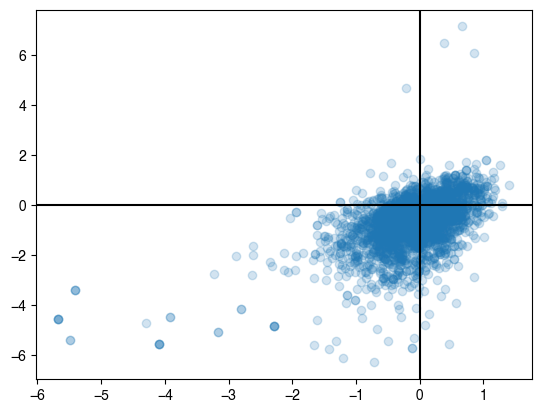

In [85]:
m3 = md1[md1['%Reads']>=40]
plt.scatter(m3['LFC_median_DMSO_Plasmid'], m3['LFC_median_KI-CDK9d-32_1000nM_Plasmid'], alpha=.2)
plt.axvline(0, color='black')
plt.axhline(0, color='black')

In [71]:
s1 = CBE_master_LFC[(CBE_master_LFC['Base_Value']=='Plasmid') & (CBE_master_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
md1 = pd.merge(CBE_editing_master, s1, on='gRNA_id')


md2 = md1.drop_duplicates(subset=['gRNA_id', 'Top_HGVSp'])
#md1[md1['Nonsense_perc']>=50] #[['LFC_median_T0_Plasmid']]


#md1.loc[]
min_nonsense = 20
md2.loc[md2['Nonsense_perc']>=min_nonsense, 'Nonsense_Guide'] = True
md2.loc[md2['Nonsense_perc']<min_nonsense, 'Nonsense_Guide'] = False

In [70]:
md2[md2['Nonsense_Guide']==True]

,gRNA_id,Gene,Total_sensor_reads,HGVSp,%Reads,Codon,Top_HGVSp,Top_HGVSp_Codon,Top_HGVSp_%Reads,WT_perc,...,KB_4000_REP1_T0,KB_4000_REP2_T0,KB_4000_REP3_T0,LFC_median_KB_2000_T0,LFC_median_KB_4000_T0,LFC_avg_KB_2000_T0,LFC_avg_KB_4000_T0,FDR_KB_2000_T0,FDR_KB_4000_T0,Nonsense_Guide
2222,gRNA_CDK19_targ_6488,CDK19,87805,W218*,62.362052,218,W218*,218,49.599681,26.354991,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2227,gRNA_CDK19_targ_6489,CDK19,41017,W218*,64.263598,218,W218*,218,32.615745,9.705732,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2239,gRNA_CDK19_targ_6490,CDK19,30792,W218*,59.642115,218,W218*,218,31.319823,16.091842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2254,gRNA_CDK19_targ_6491,CDK19,58486,W218*,72.154020,218,W218*,218,65.909790,13.685326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2329,gRNA_CDK19_targ_6501,CDK19,288044,W198*,69.763300,198,W198*,198,68.624585,17.825055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81823,gRNA_CDK6_targ_8465,CDK6,115034,Q12*,74.150251,12,Q12*,12,28.442026,13.402994,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81833,gRNA_CDK6_targ_8466,CDK6,55072,Q11*,82.953225,11,Q11*_Q12*,11,31.427949,2.002833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81851,gRNA_CDK6_targ_8467,CDK6,111221,Q11*,70.090181,11,Q11*_Q12*,11,42.730240,10.621196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
81867,gRNA_CDK6_targ_8468,CDK6,50289,Q11*,75.738233,11,Q11*,11,40.064428,3.473921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


<Axes: xlabel='Gene', ylabel='LFC_median_T0_Plasmid'>

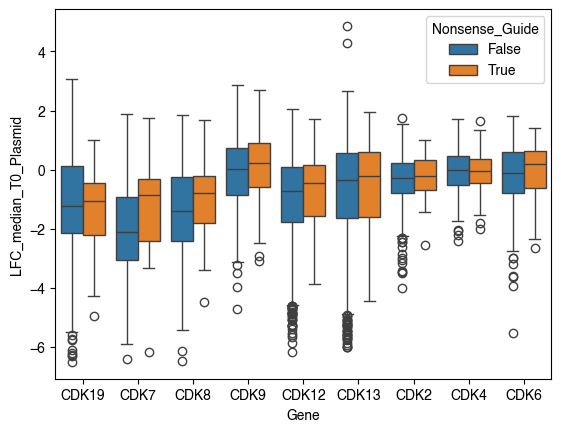

In [74]:
sns.boxplot(data=md2, x='Gene', y='LFC_median_T0_Plasmid', hue='Nonsense_Guide')